# SVM Primal

This notebook explores the primal formulation of the Support Vector Machine (SVM) algorithm for binary classification tasks. We will implement the primal SVM from scratch using gradient descent and evaluate its performance on the MNIST dataset.

## Load MNIST Dataset

In [1]:
from sklearn.datasets import fetch_openml

print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=True)
df = mnist.frame
print("MNIST dataset downloaded successfully.")

print(df.shape)
print(df.head())

MNIST dataset downloaded successfully.
(70000, 785)
   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel776  pixel777  pixel778  pixel779  pixel780  pixel781  \
0        0  ...         0         0         0         0         0         0   
1        0  ...         0         0         0         0         0         0   
2        0  ...         0         0         0         0         0         0   
3        0  ...         0         0         0         0         0         0   
4        0  ...         0         0         0         0         0         0   

   pixel78

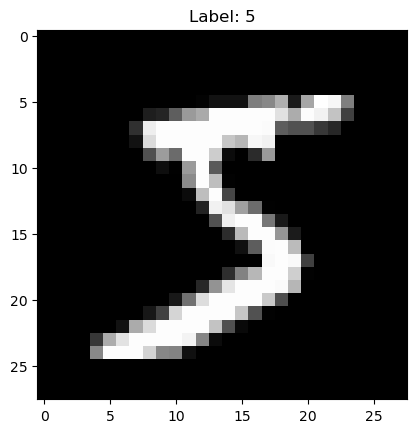

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Display the first image
plt.imshow(df.drop(columns='class').iloc[0].to_numpy().reshape(28, 28), cmap='gray')
plt.title(f"Label: {df['class'].iloc[0]}")
plt.show()

In [3]:
import sys
import os

root_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if root_dir not in sys.path:
    sys.path.append(root_dir)


## Baseline

The idea is to divide the dataset into two classes based on the morphology of the digits. To test this hypothesis, we will start with digits that clearly have different curvature, such as 1 and 8.

The HOG of the digits is then calculated and a linear SVM is trained on the HOG features before evaluating weather a dual formulation is needed.

In [4]:
from common.preprocessing_util import PreprocessingUtil as pp  

curved_digits = {'0', '6', '8', '9'}
straigth_digits = {'1', '4', '7'}

mask_df = (df['class'].isin(curved_digits)) | (df['class'].isin(straigth_digits))
df = df[mask_df]

df_bin = pp.binarize_labels(df, straigth_digits)

print(df_bin.shape)
print(df.shape)

(49556, 785)
(49556, 785)


In [5]:
hog_df = pp.hog_feature_extractor(df_bin)

print(hog_df.shape)

Extracting HOG features...
Extraction complete. New shape: (49556, 325)
(49556, 325)


In [6]:
x_train, y_train, x_test, y_test = pp.train_test_split(hog_df, 0.2)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(39645, 324)
(39645,)
(9911, 324)
(9911,)


In [7]:
from svm_primal import SVMPrimal

df_copy = x_train.copy()
df_copy['label'] = y_train

model = SVMPrimal(df_copy)
margin_violations = model.train(0.01, 50, 0.00001)

Training Started...
Epoch 0 completed ------- Violations: 7229
Training Started...
Epoch 1 completed ------- Violations: 4609
Training Started...
Epoch 2 completed ------- Violations: 4139
Training Started...
Epoch 3 completed ------- Violations: 3922
Training Started...
Epoch 4 completed ------- Violations: 3785
Training Started...
Epoch 5 completed ------- Violations: 3679
Training Started...
Epoch 6 completed ------- Violations: 3578
Training Started...
Epoch 7 completed ------- Violations: 3535
Training Started...
Epoch 8 completed ------- Violations: 3489
Training Started...
Epoch 9 completed ------- Violations: 3446
Training Started...
Epoch 10 completed ------- Violations: 3382
Training Started...
Epoch 11 completed ------- Violations: 3345
Training Started...
Epoch 12 completed ------- Violations: 3308
Training Started...
Epoch 13 completed ------- Violations: 3304
Training Started...
Epoch 14 completed ------- Violations: 3269
Training Started...
Epoch 15 completed ------- Vio

   epoch  violations
0      0        7229
1      1        4609
2      2        4139
3      3        3922
4      4        3785


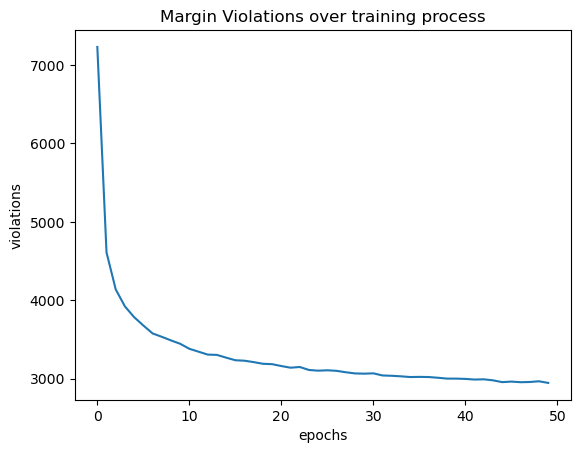

In [20]:
import matplotlib.pyplot as plt
print(margin_violations.head())

epochs = margin_violations['epoch']
violations = margin_violations['violations']

plt.plot(epochs, violations)
plt.title("Margin Violations over training process")
plt.xlabel("epochs")
plt.ylabel("violations")
plt.show()

In [21]:
output = model.predict(x_test)
correct = (output == y_test.to_numpy())

print(f"Accuracy: {correct.sum()/output.shape[0]}")

Accuracy: 0.9773988497628897


## conclusion
We can see that the test accuracy is > 0.97 which verifies the startegy.
next, I should expand the dataset to the whole range of digits and analyze the results.

In [22]:
print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=True)
df = mnist.frame
print("MNIST dataset downloaded successfully.")

print(df.shape)

MNIST dataset downloaded successfully.
(70000, 785)


In [24]:
straigth_digits = {'1', '4', '7'}
curved_digits = {'0', '2', '3', '5', '6', '8', '9'}

df_bin = pp.binarize_labels(df, straigth_digits)

print(df_bin.shape)
print(df.shape)

(70000, 785)
(70000, 785)


In [25]:
hog_df = pp.hog_feature_extractor(df_bin)

print(hog_df.shape)

Extracting HOG features...
Extraction complete. New shape: (70000, 325)
(70000, 325)


In [27]:
x_train, y_train, x_test, y_test = pp.train_test_split(hog_df, 0.2)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(56000, 324)
(56000,)
(14000, 324)
(14000,)


In [28]:
from svm_primal import SVMPrimal

df_copy = x_train.copy()
df_copy['label'] = y_train

model = SVMPrimal(df_copy)
margin_violations = model.train(0.01, 50, 0.00000001)

Training Started...
Epoch 0 completed ------- Violations: 8805
Training Started...
Epoch 1 completed ------- Violations: 5886
Training Started...
Epoch 2 completed ------- Violations: 5410
Training Started...
Epoch 3 completed ------- Violations: 5174
Training Started...
Epoch 4 completed ------- Violations: 5034
Training Started...
Epoch 5 completed ------- Violations: 4937
Training Started...
Epoch 6 completed ------- Violations: 4858
Training Started...
Epoch 7 completed ------- Violations: 4797
Training Started...
Epoch 8 completed ------- Violations: 4736
Training Started...
Epoch 9 completed ------- Violations: 4696
Training Started...
Epoch 10 completed ------- Violations: 4660
Training Started...
Epoch 11 completed ------- Violations: 4624
Training Started...
Epoch 12 completed ------- Violations: 4570
Training Started...
Epoch 13 completed ------- Violations: 4550
Training Started...
Epoch 14 completed ------- Violations: 4538
Training Started...
Epoch 15 completed ------- Vio

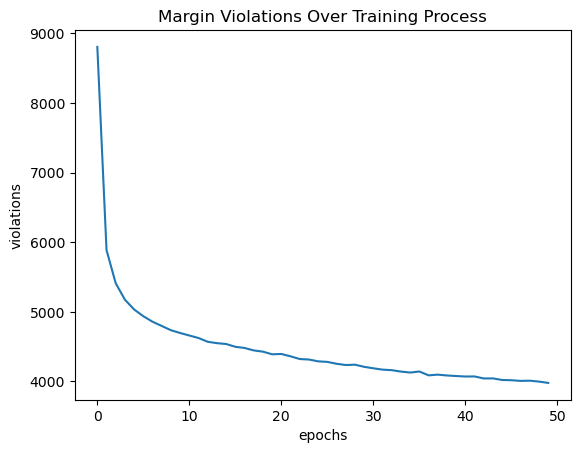

In [29]:
epochs = margin_violations['epoch']
violations = margin_violations['violations']

plt.plot(epochs, violations)
plt.title("Margin Violations Over Training Process")
plt.xlabel("epochs")
plt.ylabel("violations")
plt.show()

In [ ]:
output = model.predict(x_test)
correct = (output == y_test.to_numpy())

print(f"Accuracy: {correct.sum()/output.shape[0]}")

Accuracy: 0.9774285714285714


In [38]:
print(output)

[ 1. -1. -1. ...  1. -1. -1.]


In [56]:
false = abs(correct-1)
truePositive = ((output == np.ones(output.size)) & correct).sum()
falsePositive = ((output == np.ones(output.size)) & false).sum()
trueNegative = ((output == np.full_like(output, -1)) & correct).sum()
falseNegative = ((output == np.full_like(output, -1)) & false).sum()

print(truePositive + trueNegative)
print(falsePositive + falseNegative)
print(truePositive+trueNegative+falsePositive+falseNegative)
cm = np.array([[truePositive.item(), falsePositive.item()],[falseNegative.item(), trueNegative.item()]])
print(cm)

13684
316
14000
[[4247  135]
 [ 181 9437]]


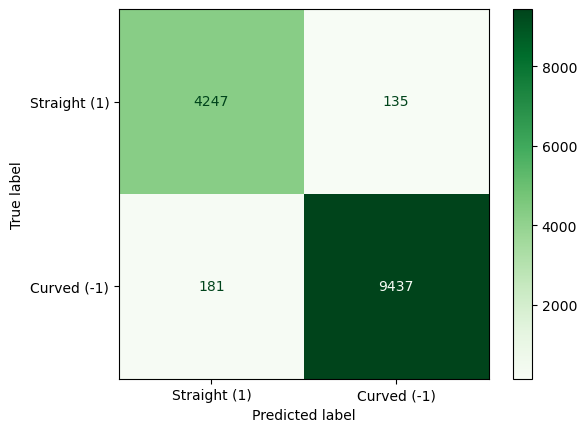

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Straight (1)', 'Curved (-1)'])
disp.plot(cmap=plt.cm.Greens)
plt.show()

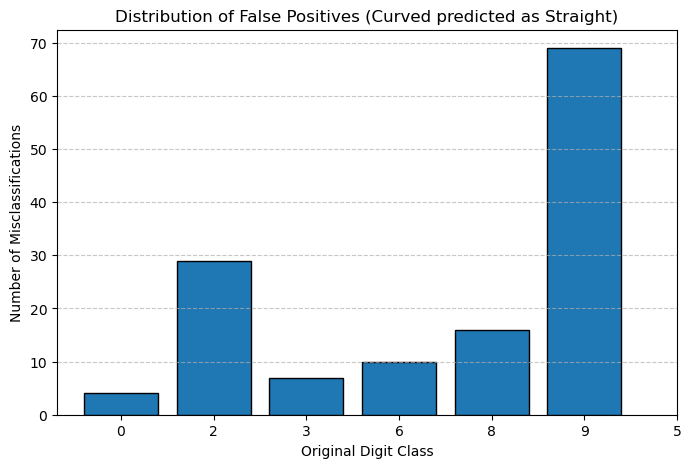

In [ ]:
from common.preprocessing_util import PreprocessingUtil
x_train_original, y_train_original, x_test_original, y_test_original = PreprocessingUtil.train_test_split(df, 0.2) # original labels

fp_indices = np.where((output == 1) & (y_test.to_numpy() == -1))[0]
fp_original_labels = y_test_original.to_numpy()[fp_indices]

unique_digits, counts = np.unique(fp_original_labels, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(unique_digits, counts, color='#1f77b4', edgecolor='black')
plt.title("Distribution of False Positives (Curved predicted as Straight)")
plt.xlabel("Original Digit Class")
plt.ylabel("Number of Misclassifications")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(['0', '2', '3', '5', '6', '8', '9']) 
plt.show()

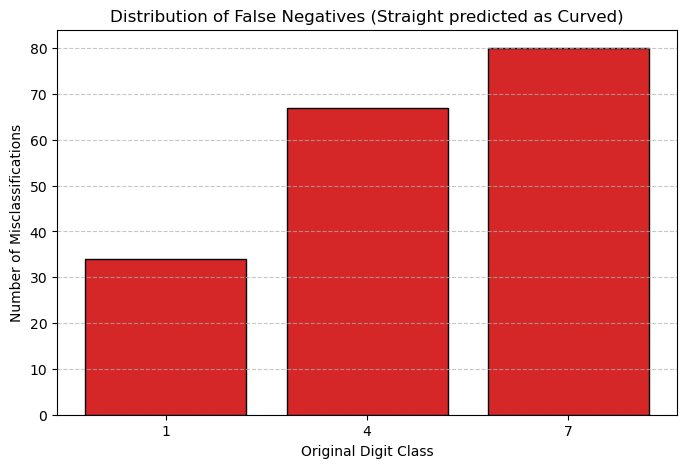

In [69]:
fn_indices = np.where((output == -1) & (y_test.to_numpy() == 1))[0]
fn_original_labels = y_test_original.to_numpy()[fn_indices]
unique_fn_digits, fn_counts = np.unique(fn_original_labels, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(unique_fn_digits, fn_counts, color='#d62728', edgecolor='black')
plt.title("Distribution of False Negatives (Straight predicted as Curved)")
plt.xlabel("Original Digit Class")
plt.ylabel("Number of Misclassifications")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(['1', '4', '7']) 
plt.show()

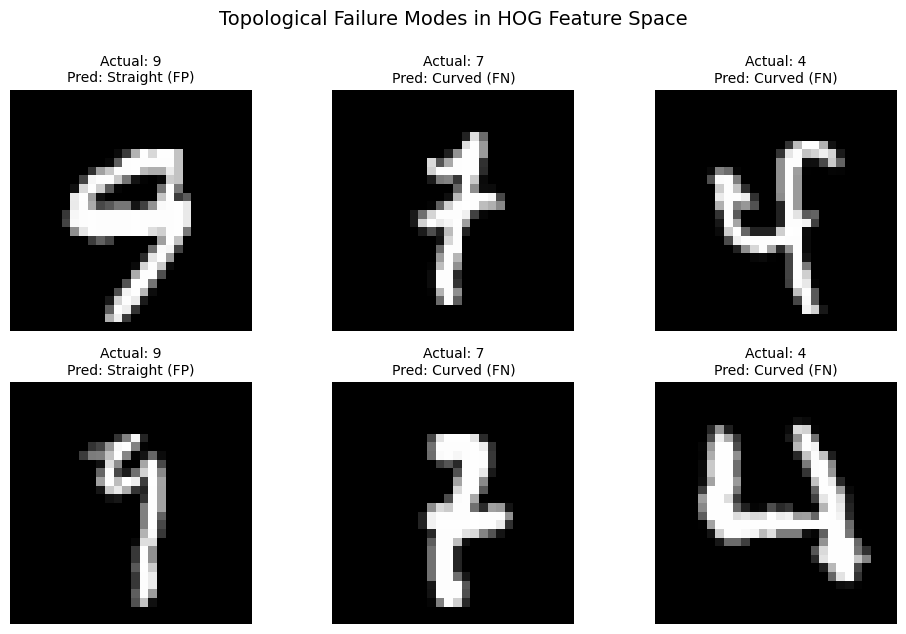

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y_test_np = y_test.to_numpy()
y_orig_np = y_test_original.to_numpy()
x_test_raw = x_test_original.to_numpy()

# 1. Find indices for the specific failure modes
# False Positives: Predicted Straight (1), Actually Curved (-1), specifically a '9'
fp_9_idx = np.where((output == 1) & (y_test_np == -1) & (y_orig_np == '9'))[0]

# False Negatives: Predicted Curved (-1), Actually Straight (1), specifically '7' or '4'
fn_7_idx = np.where((output == -1) & (y_test_np == 1) & (y_orig_np == '7'))[0]
fn_4_idx = np.where((output == -1) & (y_test_np == 1) & (y_orig_np == '4'))[0]

# 2. Setup a 2x3 Matplotlib grid to display them
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# Helper function to reshape the 784 flat array and plot
def plot_digit(ax, index, title):
    # Reshape the flat row back into a 28x28 image grid
    image = x_test_raw[index].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# 3. Plot two '9's (False Positives) in the first column
plot_digit(axes[0, 0], fp_9_idx[0], "Actual: 9\nPred: Straight (FP)")
plot_digit(axes[1, 0], fp_9_idx[1], "Actual: 9\nPred: Straight (FP)")

# 4. Plot two '7's (False Negatives) in the second column
plot_digit(axes[0, 1], fn_7_idx[0], "Actual: 7\nPred: Curved (FN)")
plot_digit(axes[1, 1], fn_7_idx[1], "Actual: 7\nPred: Curved (FN)")

# 5. Plot two '4's (False Negatives) in the third column
plot_digit(axes[0, 2], fn_4_idx[0], "Actual: 4\nPred: Curved (FN)")
plot_digit(axes[1, 2], fn_4_idx[1], "Actual: 4\nPred: Curved (FN)")

plt.tight_layout()
plt.suptitle("Topological Failure Modes in HOG Feature Space", fontsize=14, y=1.05)
plt.show()